# **Regression Model Training Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [1]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# LabelEncoder and StandardScaler for data transformation
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Mutual Information for feature selection
from sklearn.feature_selection import mutual_info_regression

# train_test_split for data splitting
from sklearn.model_selection import train_test_split

---
## A. Project Description


In [4]:
# <Student to fill this section>
group_name = "24"
student_name = "Sahaj Gupta"
student_id = "25585973"

In [5]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [8]:
# <Student to fill this section>
business_use_case_description = """
This project aims to predicts each customer’s Customer Lifetime Value (CLTV), enabling the company to prioritize high-value customers, design personalized retention
strategies and optimize marketing spend.
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
# <Student to fill this section>
business_objectives = """
Key Objectives:
1. Improve Customer Retention: Identify and prioritize high-value customers for proactive churn prevention and loyalty initiatives.

2. Enhance Revenue Forecasting: Use CLTV predictions to project future revenue streams and support strategic planning.

3. Increase Marketing ROI: Allocate marketing budget more effectively by focusing on customers who offer the highest return over time.

4. Drive Personalization at Scale: Tailor services, support and offers based on a customer’s predicted value.

5. Support Data-Driven Decision Making: Empower sales, marketing and customer success teams with actionable insights derived from CLTV scores.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
1. Executive Leadership: The CLTV model will support long-term revenue planning by providing strategic insights into customer value, enhancing forecast accuracy and
justifying investment decisions through measurable ROI improvements.

2. Marketing Team: The model enables precision targeting of high-value customers, reduces churn risk through proactive engagement and improves marketing ROI by focusing
resources on segments that contribute most to revenue.

3. Customer Service Team: Insights from CLTV predictions will help the service team prioritize high-value customers, personalize support experiences and identify at-risk
customers for retention interventions.

4. Product Team: Understanding customer value segments empowers the product team to tailor offerings, optimize pricing strategies and develop new features aligned with
high-value customer preferences.

5. Data & Analytics Team: Responsible for ensuring model robustness, scalability, and accuracy. The analytics team will monitor KPIs, update the model with new data and
ensure explainability and compliance with internal standards.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets

In [14]:
# <Student to fill this section>
try:
  df0 = pd.read_csv(folder_path / "customer_details.csv")
  df1 = pd.read_csv(folder_path / "customer_satisfaction.csv")
  df2 = pd.read_csv(folder_path / "customer_subscriptions.csv")
  df3 = pd.read_csv(folder_path / "customer_usage.csv")
except Exception as e:
  print(e)

In [15]:
# <Student to fill this section>
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11688 entries, 0 to 11687
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         11688 non-null  int64  
 1   customer_id        11688 non-null  object 
 2   full_name          11688 non-null  object 
 3   gender             11688 non-null  object 
 4   dob                11688 non-null  object 
 5   age                11688 non-null  int64  
 6   is_young_adult     11688 non-null  object 
 7   is_senior          11688 non-null  object 
 8   birth_country      11688 non-null  object 
 9   passport_number    11688 non-null  object 
 10  passport_expiry    11688 non-null  object 
 11  phone_number       11688 non-null  object 
 12  email              11688 non-null  object 
 13  marital_status     11688 non-null  object 
 14  has_children       11688 non-null  object 
 15  number_dependents  11688 non-null  int64  
 16  Gender             168

In [16]:
df0 = df0.drop(columns=['Unnamed: 0'])

In [17]:
df0.duplicated().sum()

np.int64(2957)

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15774 entries, 0 to 15773
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   15774 non-null  int64 
 1   customer_id  15774 non-null  object
 2   nps          15774 non-null  int64 
 3   cltv         15774 non-null  int64 
 4   reason       4189 non-null   object
dtypes: int64(3), object(2)
memory usage: 616.3+ KB


In [19]:
df1 = df1.drop(columns=['Unnamed: 0'])

In [20]:
df1.duplicated().sum()

np.int64(8731)

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12111 entries, 0 to 12110
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            12111 non-null  int64  
 1   customer_id           12111 non-null  object 
 2   has_referred_friend   12111 non-null  object 
 3   number_referrals      12111 non-null  int64  
 4   month_tenure          12081 non-null  float64
 5   plan                  5369 non-null   object 
 6   phone_plan            12111 non-null  object 
 7   has_multiple_lines    12111 non-null  object 
 8   broadband_plan        12111 non-null  object 
 9   broadband_type        9407 non-null   object 
 10  online_security       12111 non-null  object 
 11  online_backup         12111 non-null  object 
 12  device_protection     12111 non-null  object 
 13  premium_tech_support  12111 non-null  object 
 14  unlimited_data        11849 non-null  object 
 15  contract           

In [22]:
df2 = df2.drop(columns=['Unnamed: 0'])

In [23]:
df2.duplicated().sum()

np.int64(5068)

In [24]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11125 entries, 0 to 11124
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         11125 non-null  int64  
 1   customer_id                        11125 non-null  object 
 2   avg_monthly_international_charges  11125 non-null  float64
 3   avg_monthly_download_in_gb         11125 non-null  int64  
 4   monthly_charge                     11125 non-null  float64
 5   total_charges                      10834 non-null  float64
 6   total_refunds                      10611 non-null  float64
 7   total_extra_data_charges           10858 non-null  float64
 8   total_international_charges        9142 non-null   float64
 9   total_revenue                      8302 non-null   float64
dtypes: float64(7), int64(2), object(1)
memory usage: 869.3+ KB


In [25]:
df3 = df3.drop(columns=['Unnamed: 0'])

In [26]:
df3.duplicated().sum()

np.int64(4082)

In [27]:
# <Student to fill this section>
from functools import reduce

# Drop index columns and prepare clean DataFrames
dfs = [df0, df1, df2, df3]

# Full outer merge on 'customer_id'
df_merged = reduce(lambda left, right: pd.merge(left, right, on='customer_id', how='outer'), dfs)

# Summary
print("Final merged shape:", df_merged.shape)
df_merged.info()


Final merged shape: (62870, 62)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62870 entries, 0 to 62869
Data columns (total 62 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        62870 non-null  object 
 1   full_name                          62870 non-null  object 
 2   gender                             62870 non-null  object 
 3   dob                                62870 non-null  object 
 4   age                                62870 non-null  int64  
 5   is_young_adult                     62870 non-null  object 
 6   is_senior                          62870 non-null  object 
 7   birth_country                      62870 non-null  object 
 8   passport_number                    62870 non-null  object 
 9   passport_expiry                    62870 non-null  object 
 10  phone_number                       62870 non-null  object 
 11  email                 

In [28]:
# Descriptive Statistics of the merged dataset
df_merged.describe()

,age,number_dependents,building_number,postcode,cc_number,cc_security_code,nps,cltv,number_referrals,month_tenure,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue
count,62870.000000,62870.000000,1688.000000,1688.000000,1.688000e+03,1688.000000,61182.000000,61182.000000,61182.000000,60902.000000,61182.000000,61182.000000,61182.000000,59705.000000,58510.000000,59516.000000,50660.000000,46283.000000
mean,46.856466,0.520232,171.125000,3102.980450,4.149108e+17,884.476303,3.252198,4407.900232,1.908927,33.291944,22.969095,20.560148,64.390034,2294.942602,1.974827,7.344748,773.175624,3017.257076
std,17.024647,1.015443,270.512982,1731.195095,1.300788e+18,1509.431934,1.185873,1188.505415,2.955947,24.745133,15.307937,20.803149,29.941739,2245.906974,7.892198,25.556164,855.954022,2762.330795
min,18.000000,0.000000,0.000000,202.000000,6.040156e+10,1.000000,1.000000,2003.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.400000
25%,33.000000,0.000000,6.000000,2581.750000,1.800107e+14,277.000000,3.000000,3442.000000,0.000000,9.000000,9.880000,3.000000,35.200000,422.400000,0.000000,0.000000,67.680000,665.090000
50%,46.000000,0.000000,39.000000,2689.000000,3.512907e+15,562.000000,3.000000,4586.000000,0.000000,31.000000,23.000000,17.000000,70.150000,1405.300000,0.000000,0.000000,435.680000,2235.410000
75%,60.000000,1.000000,189.000000,2962.000000,4.663844e+15,821.000000,4.000000,5353.000000,3.000000,57.000000,35.860000,27.000000,89.600000,3928.300000,0.000000,0.000000,1271.900000,4698.570000
max,92.000000,9.000000,998.000000,9988.000000,4.989705e+18,9960.000000,5.000000,6500.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.570000,150.000000,3564.720000,11979.340000


### C.2 Define Target variable

In [29]:
# <Student to fill this section>
target_definition_explanations = """
Customer Lifetime Value (CLTV): This represents the total monetary value a business can expect from a customer over the entire duration of their relationship. It is a key
performance metric that helps quantify how profitable a customer is. A higher CLTV indicates that the customer contributes more revenue over time and is considered a
high-value customer.
Customers with high CLTV should be prioritized for retention strategies such as personalized offers, loyalty rewards or premium support. If such customers show signs of
churn (e.g., reduced usage, lower satisfaction), it may lead to significant revenue loss.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [31]:
# <Student to fill this section>

target_name = 'cltv'

### C.4 Explore Target variable

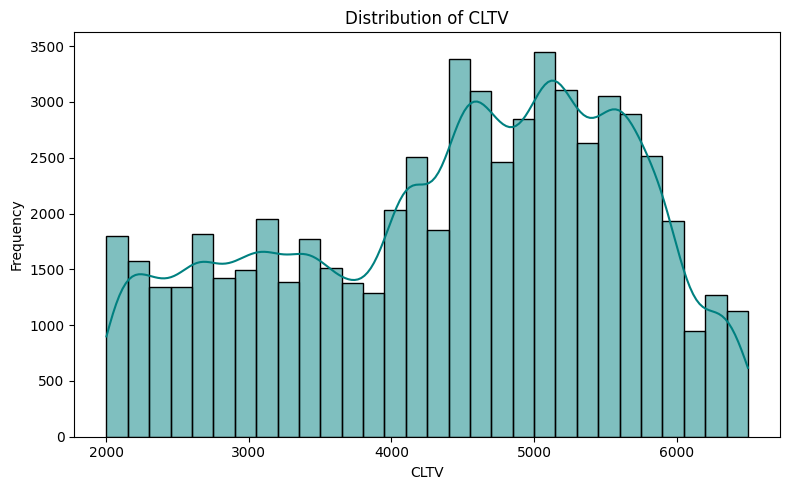

In [32]:
# <Student to fill this section>
plt.figure(figsize=(8, 5))
sns.histplot(df_merged[target_name], bins=30, kde=True, color='teal')
plt.title('Distribution of CLTV')
plt.xlabel('CLTV')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [33]:
# <Student to fill this section>
target_distribution_explanations = """
1. The distribution is bimodal to multimodal, indicating that CLTV values cluster around multiple peaks. This suggests the presence of different customer segments with
varying levels of value to the business. It does not follow a normal distribution and is fairly spread out, showing a wide range of CLTV values.
2. CLTV values range approximately from 2000 to 6500, with most values concentrated between 3000 and 6000. The plot shows a reasonably uniform frequency in the lower
range (2000–4000) but peaks significantly between 4500 and 5500, where the highest frequencies occur.
3. There is no strong skew and the distribution appears relatively symmetric around the main peak. The tail on the right suggests a moderate presence of higher-value
outliers, but they are not extreme or isolated.
"""

In [34]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore "Age"

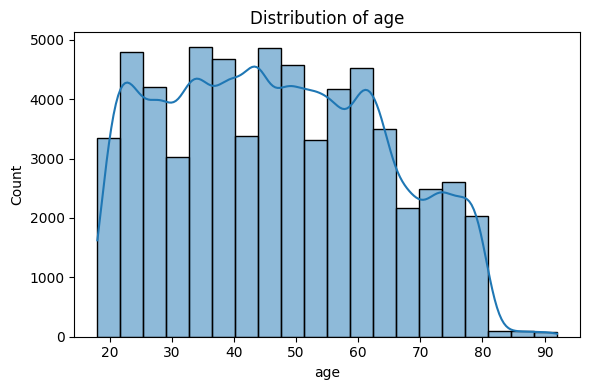

In [35]:
# <Student to fill this section>
plt.figure(figsize=(6, 4))
sns.histplot(df_merged['age'], kde=True, bins=20)
plt.title(f'Distribution of age')
plt.tight_layout()
plt.show()

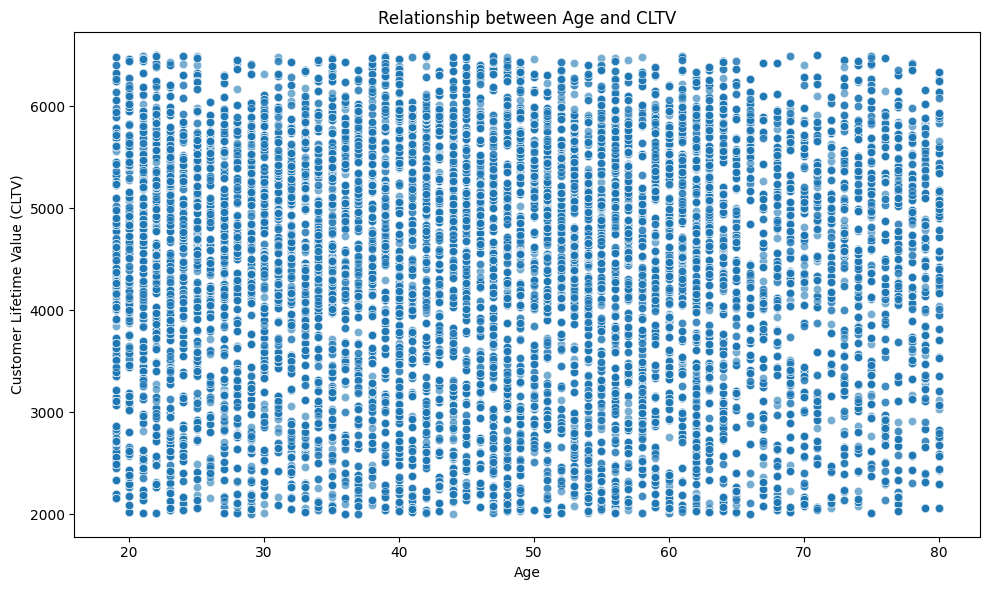

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='age', y=target_name, alpha=0.6)
plt.title('Relationship between Age and CLTV')
plt.xlabel('Age')
plt.ylabel('Customer Lifetime Value (CLTV)')
plt.tight_layout()
plt.show()

In [37]:
# <Student to fill this section>
feature1_insights = """
1. The age distribution spans from around 18 to 90 years, with the majority of customers concentrated between 25 and 65. The distribution is fairly uniform with some dips
and peaks, suggesting no dominant age group but with slightly fewer customers in the younger (under 25) and older (above 70) brackets.
2. The scatter plot shows no clear linear or non-linear relationship between customer age and their lifetime value (CLTV). The data points are densely packed and randomly
distributed across the entire age spectrum implying age, on its own, does not significantly explain variations in CLTV.
3. Age is likely a low-impact predictor of CLTV. It may not add significant value to a regression model unless used in interaction with other features.
"""

In [38]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### C.6 Explore "nps"

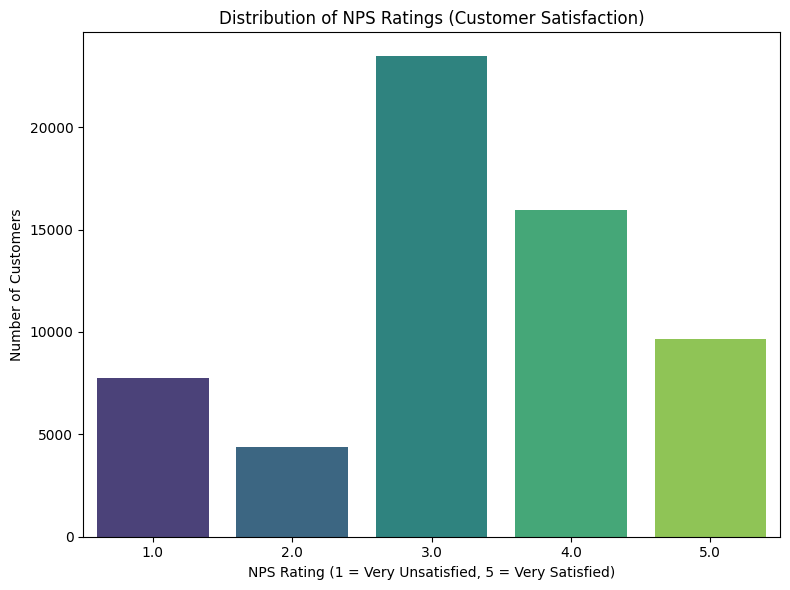

In [39]:
# <Student to fill this section>
plt.figure(figsize=(8, 6))
sns.countplot(data=df_merged, x='nps', palette='viridis')

plt.title('Distribution of NPS Ratings (Customer Satisfaction)')
plt.xlabel('NPS Rating (1 = Very Unsatisfied, 5 = Very Satisfied)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

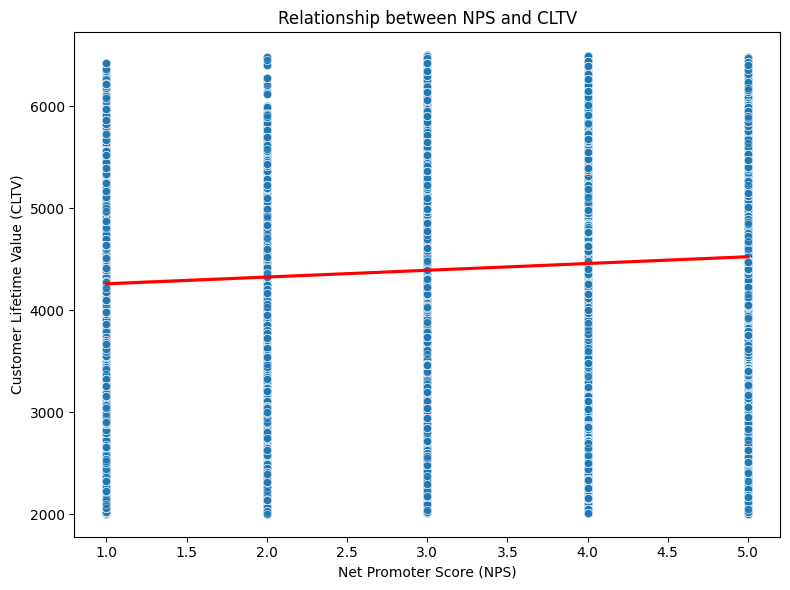

In [40]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_merged, x='nps', y=target_name, alpha=0.6)
sns.regplot(data=df_merged, x='nps', y=target_name, scatter=False, color='red')  # trend line
plt.title('Relationship between NPS and CLTV')
plt.xlabel('Net Promoter Score (NPS)')
plt.ylabel('Customer Lifetime Value (CLTV)')
plt.tight_layout()
plt.show()

In [41]:
# <Student to fill this section>
feature_2_insights = """
1. A large proportion of customers have rated their satisfaction as 3 or 4. There are fewer very dissatisfied (ratings 1 or 2) and fewer highly satisfied customers
(rating 5). This suggests that the company maintains an average level of customer satisfaction. However, the fact that fewer customers are rating a perfect 5 could point
to gaps in exceeding customer expectations.
2. A weak positive trend can be observed — customers with higher NPS scores tend to have slightly higher CLTV, but the relationship is not very strong or tightly
correlated. Customer satisfaction has a moderate but notable impact on lifetime value. Satisfied customers are more likely to stay longer and contribute more revenue over
time. Initiatives should focus on converting "passive" customers (rating 3) into promoters (rating 5) through better service, proactive support or loyalty rewards.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore "Month_Tenure"

In [43]:
# <Student to fill this section>
df_merged['month_tenure'].describe()

,month_tenure
count,60902.000000
mean,33.291944
std,24.745133
min,1.000000
25%,9.000000
50%,31.000000
75%,57.000000
max,72.000000


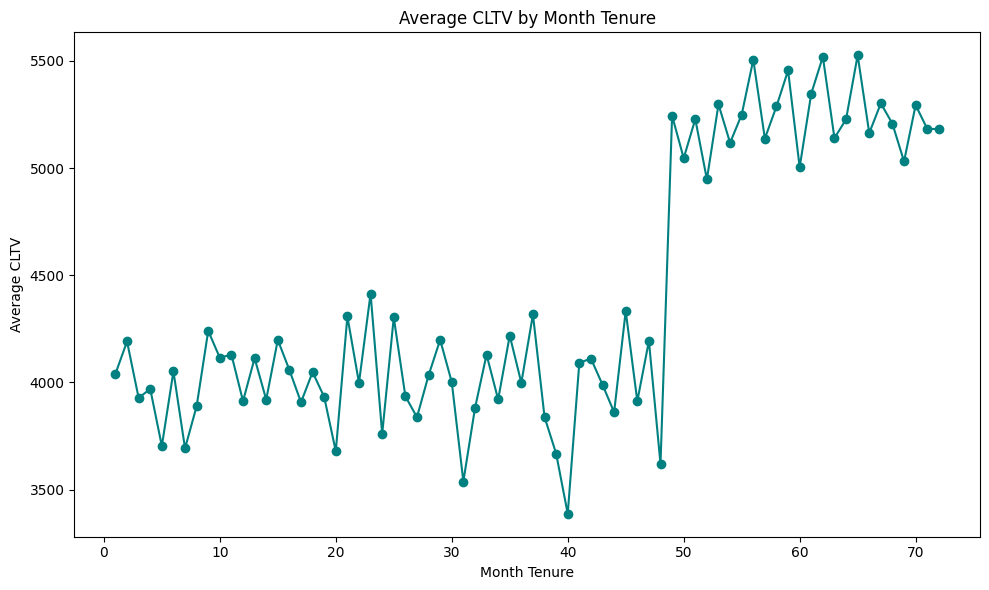

In [44]:
avg_cltv_by_tenure = df_merged.groupby('month_tenure')[target_name].mean()

# Plot the trend
plt.figure(figsize=(10, 6))
avg_cltv_by_tenure.plot(kind='line', marker='o', color='teal')
plt.title('Average CLTV by Month Tenure')
plt.xlabel('Month Tenure')
plt.ylabel('Average CLTV')
plt.tight_layout()
plt.show()

In [45]:
# <Student to fill this section>
feature_3_insights = """
1. For the tenure between 0–47 months, the average CLTV hovers between approximately $3,500 to $4,400, with significant monthly fluctuations. The values are relatively
lower and less consistent during this period. This indicates that early to mid-tenure customers contribute moderate and unstable revenue.
2. There is a sudden and significant jump in average CLTV starting at month 48, where values leap above $5,000. This transition is sharp and sustained suggesting customers
who reach the 4-year mark become significantly more valuable. This may indicate loyalty milestones (e.g., discounted upgrades, loyalty bonuses) or customer behavioral
maturity (e.g., full product adoption, bundling of services).
3. For the tenure between 48–72 months, the average CLTV stabilizes at a high level, fluctuating in the $5,000–$5,500 range. Despite minor month-to-month noise, the trend
shows these customers consistently have high value leading to conclusion that long-term customers are reliably profitable and show strong retention.
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.7 Explore "Contract Type"

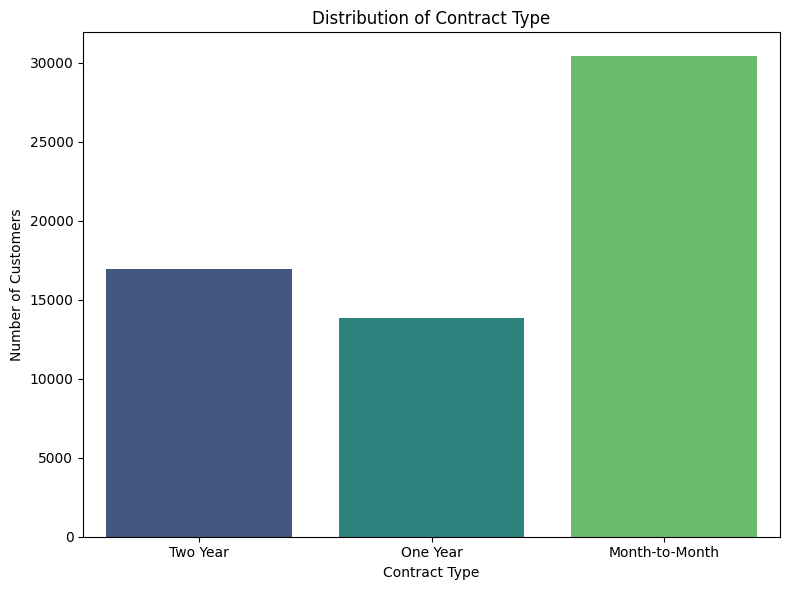

In [47]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_merged, x='contract', palette='viridis')
plt.title('Distribution of Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

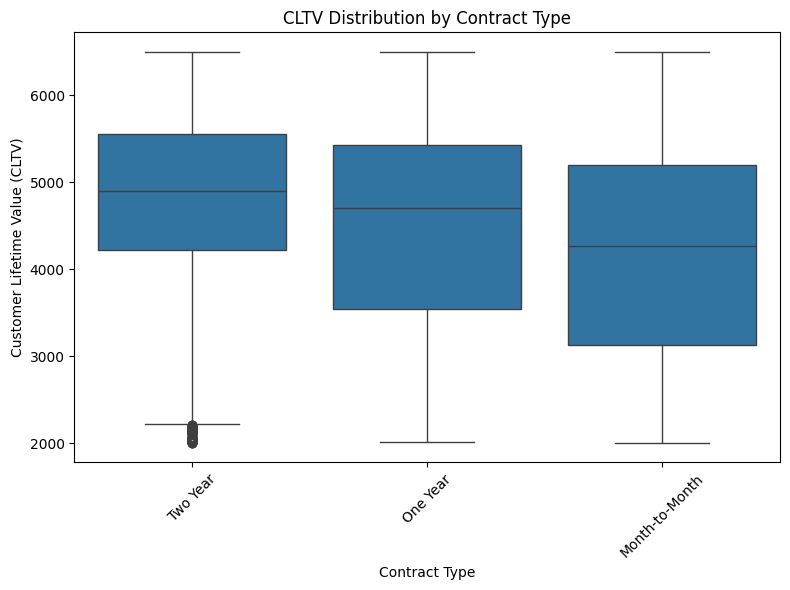

In [48]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='contract', y=target_name, data=df_merged)
plt.title('CLTV Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Lifetime Value (CLTV)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# <Student to fill this section>
feature_4_insights = """
1. Month-to-Month contracts dominate the customer base in the distribution of contract type, followed by Two-Year and One-Year contracts. This suggests customer preference
for flexibility, possibly driven by trial behavior or lack of long-term commitment. The possibility of high churn risk exists within the month-to-month segment, even
though they represent the largest portion of the customer base.
2. Two-Year contracts have the highest median and upper-range CLTV, followed by One-Year and finally Month-to-Month, which has the lowest. Month-to-month contracts show
greater variability and more low-value outliers. Two-Year contracts have a tighter distribution around higher values, indicating stable, high-value customers.
3. This suggests that contract type is a strong predictor of CLTV. Long-term contracts (especially two-year) drive higher and more consistent customer value. Promotions
encouraging transition to longer-term contracts could significantly enhance revenue per user.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.8 Explore "Total_Revenue"

In [51]:
df_merged['total_revenue'].describe()

,total_revenue
count,46283.000000
mean,3017.257076
std,2762.330795
min,21.400000
25%,665.090000
50%,2235.410000
75%,4698.570000
max,11979.340000


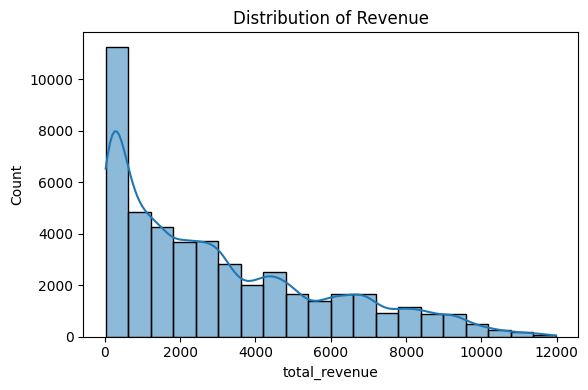

In [52]:
plt.figure(figsize=(6, 4))
sns.histplot(df_merged['total_revenue'], kde=True, bins=20)
plt.title(f'Distribution of Revenue')
plt.tight_layout()
plt.show()

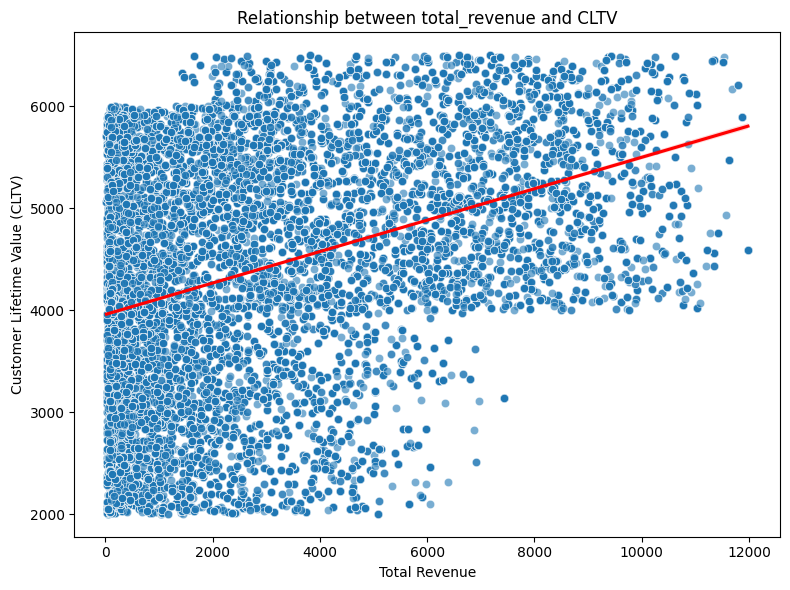

In [53]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_merged, x='total_revenue', y=target_name, alpha=0.6)
sns.regplot(data=df_merged, x='total_revenue', y=target_name, scatter=False, color='red')  # trend line
plt.title('Relationship between total_revenue and CLTV')
plt.xlabel('Total Revenue')
plt.ylabel('Customer Lifetime Value (CLTV)')
plt.tight_layout()
plt.show()

In [54]:
# <Student to fill this section>
feature_5_insights = """
1. The total revenue distribution is right-skewed indicating most customers generate lower total revenue. A small number of customers account for high revenue (long-tail pattern).
This shows that customer base is likely composed of many low-revenue users and a small set of high-value ones. Identifying and nurturing these high-value segments is key
for profitability.
2. Positive linear trend between total revenue and CLTV. As total revenue increases, CLTV also increases, though there is noticeable spread (some variance unexplained by
revenue alone). CLTV correlates with revenue as expected but is not determined by revenue alone — suggesting other influencing factors (e.g., churn risk, service usage,
satisfaction).
"""

In [55]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

---
## D. Feature Selection


In [56]:
df_feat_sel = df_merged.copy()

In [57]:
# Removing personal and irrelevant features from the dataset
df_feat_sel = df_feat_sel.drop(['customer_id', 'Gender', 'profile', 'locale', 'prefix', 'first_name', 'last_name', 'full_name', 'dob', 'passport_number', 'phone_number', 'email', 'secondary_address', 'postcode', 'building_number', 'street_name', 'street_suffix', 'city', 'state_abbr', 'address', 'cc_number', 'cc_expiry', 'cc_security_code', 'company_name', 'company_suffix', 'user_agent'], axis=1)

In [58]:
df_feat_sel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62870 entries, 0 to 62869
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             62870 non-null  object 
 1   age                                62870 non-null  int64  
 2   is_young_adult                     62870 non-null  object 
 3   is_senior                          62870 non-null  object 
 4   birth_country                      62870 non-null  object 
 5   passport_expiry                    62870 non-null  object 
 6   marital_status                     62870 non-null  object 
 7   has_children                       62870 non-null  object 
 8   number_dependents                  62870 non-null  int64  
 9   nps                                61182 non-null  float64
 10  cltv                               61182 non-null  float64
 11  reason                             16194 non-null  obj

In [59]:
# Checking for duplicates in the merged dataset to ensure data integrity and prevent bias or inflated mutual information scores due to repeated observations
df_feat_sel.duplicated().sum()

np.int64(54139)

In [60]:
df_feat_sel.drop_duplicates(inplace=True)

In [61]:
df_feat_sel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8731 entries, 0 to 62862
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             8731 non-null   object 
 1   age                                8731 non-null   int64  
 2   is_young_adult                     8731 non-null   object 
 3   is_senior                          8731 non-null   object 
 4   birth_country                      8731 non-null   object 
 5   passport_expiry                    8731 non-null   object 
 6   marital_status                     8731 non-null   object 
 7   has_children                       8731 non-null   object 
 8   number_dependents                  8731 non-null   int64  
 9   nps                                7043 non-null   float64
 10  cltv                               7043 non-null   float64
 11  reason                             1869 non-null   object 
 

In [62]:
# Removing missing values from the target variable
df_feat_sel = df_feat_sel.dropna(subset=['cltv'])

In [63]:
df_feat_sel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 1 to 62862
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             7043 non-null   object 
 1   age                                7043 non-null   int64  
 2   is_young_adult                     7043 non-null   object 
 3   is_senior                          7043 non-null   object 
 4   birth_country                      7043 non-null   object 
 5   passport_expiry                    7043 non-null   object 
 6   marital_status                     7043 non-null   object 
 7   has_children                       7043 non-null   object 
 8   number_dependents                  7043 non-null   int64  
 9   nps                                7043 non-null   float64
 10  cltv                               7043 non-null   float64
 11  reason                             1869 non-null   object 
 

In [64]:
# Imputing missing values in numerical columns as mutual information cannot handle NaNs
df_feat_sel['month_tenure'].fillna(df_feat_sel['month_tenure'].median(), inplace=True)
df_feat_sel['total_charges'].fillna(df_feat_sel['total_charges'].median(), inplace=True)
df_feat_sel['total_refunds'].fillna(0, inplace=True)
df_feat_sel['total_extra_data_charges'].fillna(0, inplace=True)
df_feat_sel['total_international_charges'].fillna(df_feat_sel['total_international_charges'].median(), inplace=True)
df_feat_sel['total_revenue'].fillna(df_feat_sel['total_revenue'].median(), inplace=True)


<ipython-input-64-dd89551d0d02>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feat_sel['month_tenure'].fillna(df_feat_sel['month_tenure'].median(), inplace=True)
<ipython-input-64-dd89551d0d02>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feat_sel['total_charges'].fillna(df_feat_sel['total_charges'].median(), inplace=True)
<ipython-input-64-dd89551d0d02>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feat_sel['total_r

In [65]:
df_feat_sel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 1 to 62862
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             7043 non-null   object 
 1   age                                7043 non-null   int64  
 2   is_young_adult                     7043 non-null   object 
 3   is_senior                          7043 non-null   object 
 4   birth_country                      7043 non-null   object 
 5   passport_expiry                    7043 non-null   object 
 6   marital_status                     7043 non-null   object 
 7   has_children                       7043 non-null   object 
 8   number_dependents                  7043 non-null   int64  
 9   nps                                7043 non-null   float64
 10  cltv                               7043 non-null   float64
 11  reason                             1869 non-null   object 
 

In [66]:
feat_sel_mi = df_feat_sel.copy()

In [67]:
# Applying Mutual Information Gain for Feature Selection
selected_features = feat_sel_mi.columns.tolist()

for feat in selected_features:
    if feat_sel_mi[feat].dtype == 'object':
        feat_sel_mi[feat] = LabelEncoder().fit_transform(feat_sel_mi[feat])

feat_sel_mi_x = feat_sel_mi.drop(target_name, axis=1)
feat_sel_mi_y = feat_sel_mi[target_name]

mi_scores = mutual_info_regression(feat_sel_mi_x, feat_sel_mi_y)

feat_sel_mi_scores = pd.DataFrame({'Feature': feat_sel_mi_x.columns, 'Mutual Information Score': mi_scores})
feat_sel_mi_scores = feat_sel_mi_scores.sort_values(by='Mutual Information Score', ascending=False)
feat_sel_mi_scores

,Feature,Mutual Information Score
13,month_tenure,0.197842
30,total_charges,0.115041
34,total_revenue,0.101378
14,plan,0.076776
33,total_international_charges,0.063726
24,contract,0.049133
29,monthly_charge,0.028265
16,has_multiple_lines,0.024553
20,online_backup,0.022562
18,broadband_type,0.020330


In [68]:
# <Student to fill this section>
least_contributing_features = ['birth_country','avg_monthly_download_in_gb','gender','age','phone_plan','passport_expiry','is_senior','paperless_billing',
                               'device_protection','total_extra_data_charges','total_refunds']
features_list = [feature for feature in df_feat_sel.columns if feature not in least_contributing_features]
features_list

['is_young_adult',
 'marital_status',
 'has_children',
 'number_dependents',
 'nps',
 'cltv',
 'reason',
 'has_referred_friend',
 'number_referrals',
 'month_tenure',
 'plan',
 'has_multiple_lines',
 'broadband_plan',
 'broadband_type',
 'online_security',
 'online_backup',
 'premium_tech_support',
 'unlimited_data',
 'contract',
 'payment_method',
 'avg_monthly_international_charges',
 'monthly_charge',
 'total_charges',
 'total_international_charges',
 'total_revenue']

In [69]:
# <Student to fill this section>
feature_selection_insights = """
Below two approaches are employed for feature selection:

1. Removing Personally Identifiable Information (PII): By dropping PII and non-contributing features such as full_name, email, phone_number and address-related fields
like secondary_address, street_name and postcode, we ensure that the dataset was optimized for machine learning model training and free from noise. These attributes do
not have a direct influence on a customer's lifetime value and may introduce unnecessary complexity or ethical concerns if included in a predictive model. In addition,
identifiers like customer_id were removed, as they are unique to each record and offer no predictive value, while potentially leading to overfitting.

2. Applied Mutual Information Gain: This measures the amount of shared information between a feature and the target variable. It works with both categorical and numerical
data, and unlike correlation, it captures non-linear relationships. It provides a numerical value for how much information a feature shares with the target. A higher MI
score indicates the feature is more informative and relevant. It also contributes in reducing dimensionality, avoiding overfitting and making the model faster & more
interpretable.

Result: Below features showed minimal information gain:
['birth_country','avg_monthly_download_in_gb','gender','age','phone_plan','passport_expiry','is_senior','paperless_billing','device_protection','total_extra_data_charges',
'total_refunds']
By using the above feature selection techniques, we have eliminated all the irrelevant features and features that have low mutual information gain score, reducing the
count of number of features from 62 to 25.

"""

In [70]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_insights', value=feature_selection_insights)

---
## E. Data Cleaning

### E.1 Fixing Null Values

In [71]:
# <Student to fill this section>
df_clean = df_feat_sel[features_list].copy()
df_clean.head()

,is_young_adult,marital_status,has_children,number_dependents,nps,cltv,reason,has_referred_friend,number_referrals,month_tenure,...,online_backup,premium_tech_support,unlimited_data,contract,payment_method,avg_monthly_international_charges,monthly_charge,total_charges,total_international_charges,total_revenue
1,Yes,No,No,0,4.0,3733.0,NaN,No,0.0,39.0,...,No,No,No,Two Year,Credit Card,29.79,20.70,762.45,1161.81,1924.26
7,Yes,Yes,Yes,2,5.0,4152.0,NaN,Unknown,6.0,72.0,...,No,No,No,One Year,Bank Withdrawal,18.14,23.30,1623.15,1306.08,2929.23
39,No,Yes,No,0,4.0,6483.0,NaN,Yes,1.0,71.0,...,Yes,Yes,Yes,Two Year,Bank Withdrawal,18.42,90.35,6325.25,1307.82,7633.07
40,No,Yes,No,0,1.0,4196.0,Attitude of support person,Unknown,3.0,65.0,...,No,No,Yes,Month-to-Month,Bank Withdrawal,18.39,105.25,6786.40,409.36,7981.75
52,No,Yes,No,0,2.0,4873.0,Competitor offered more data,Unknown,2.0,42.0,...,No,No,Yes,Month-to-Month,Bank Withdrawal,10.79,50.25,2203.65,453.18,2130.44


In [72]:
# Checking Missing values count in each feature
df_clean.isnull().sum()

,0
is_young_adult,0
marital_status,0
has_children,0
number_dependents,0
nps,0
cltv,0
reason,5174
has_referred_friend,0
number_referrals,0
month_tenure,0


In [73]:
# Checking distribution of feature - 'plan' to decide imputation strategy
df_clean['plan'].value_counts()

,count
plan,
Plan B,824
Plan E,805
Plan D,602
Plan A,520
Plan C,415


In [74]:
# Checking distribution of feature - 'broadband_type' to decide imputation strategy
df_clean['broadband_type'].value_counts()

,count
broadband_type,
Fiber Optic,3023
DSL,1646
Cable,829


In [75]:
# Imputation of missing values
# 'plan' and 'broadband_type' are imputed with value 'Unknown' as no single plan or broadband type is dominant and imputing with mode may introduce bias and mislead the model
# 'unlimited_data' and 'payment_method' are imputed with mode as missing value count is only ~1%, so the risk of distortion is low.
# Missing value in 'reason' is filled with 'Not Churned' as empty reason indicates customer is associated with the company.

df_clean['reason'] = df_clean['reason'].fillna('Not Churned')
df_clean['plan'] = df_clean['plan'].fillna('Unknown')
df_clean['broadband_type'] = df_clean['broadband_type'].fillna('Unknown')
df_clean['unlimited_data'] = df_clean['unlimited_data'].fillna(df_clean['unlimited_data'].mode()[0])
df_clean['payment_method'] = df_clean['payment_method'].fillna(df_clean['payment_method'].mode()[0])


In [76]:
df_clean.isnull().sum()

,0
is_young_adult,0
marital_status,0
has_children,0
number_dependents,0
nps,0
cltv,0
reason,0
has_referred_friend,0
number_referrals,0
month_tenure,0


In [77]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Null values indicate missing or unknown information, which can lead to incorrect insights, biased results, errors or inaccurate model behavior. Fixing them improves the
reliability of the data-driven decisions and improves improves model accuracy and performance.
"""

In [78]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Fixing "Duplicate Values"


In [79]:
# <Student to fill this section>
# Checking duplicate count

df_clean.duplicated().sum()

np.int64(0)

In [80]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Duplicates were already removed during the feature selection process.
Importance of Fixing Duplicate Values:

1. Prevents Model Bias: Duplicate records can cause certain observations to be overrepresented, biasing the model toward those values and distorting predictions.
2. Ensures Data Integrity: Removing duplicates helps maintain the accuracy and trustworthiness of the dataset, especially in decision-making scenarios.
3. Improves Model Efficiency: Duplicate rows unnecessarily increase the dataset size, leading to longer training times and more resource consumption without adding value.
4. Reduces Overfitting Risk: Repeated patterns can make the model learn non-generalizable rules, reducing its ability to perform well on new or unseen data.
"""

In [81]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Fixing "Outliers"


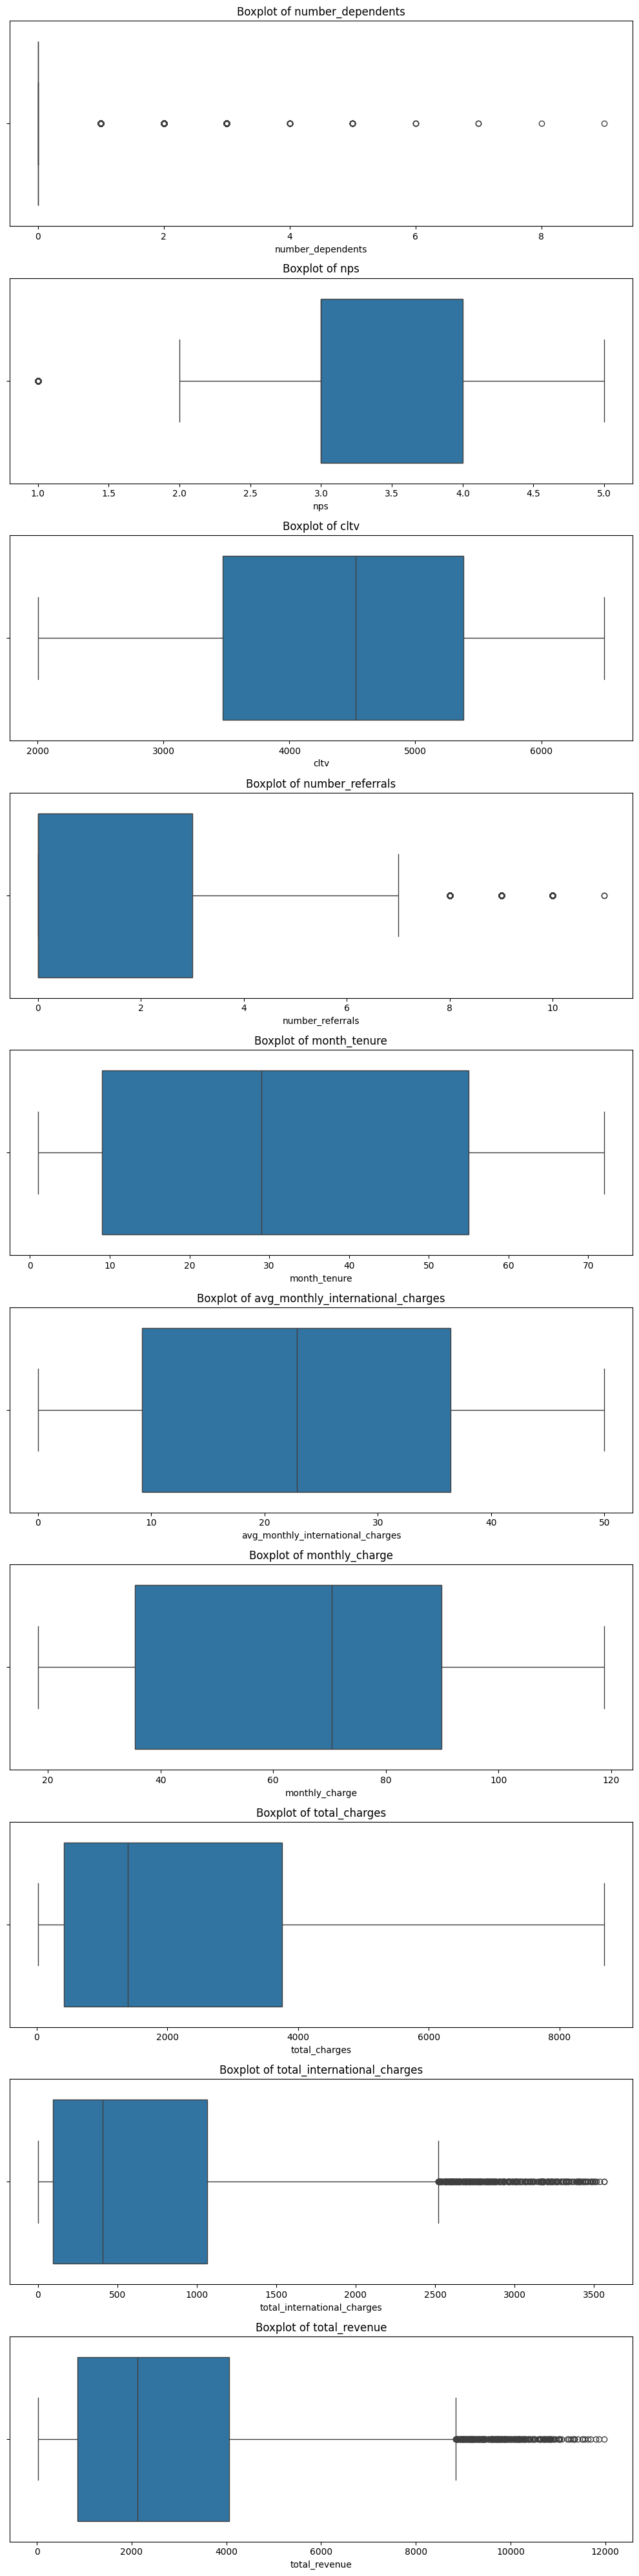

In [82]:
# <Student to fill this section>
# Checking for outliers in the numerical features

num_features = []

for i in df_clean.columns:
    if df_clean[i].dtypes != 'object':
        num_features.append(i)

plt.figure(figsize=(10, len(num_features) * 4))
for i, column in enumerate(num_features, 1):
    plt.subplot(len(num_features), 1, i)
    sns.boxplot(x = df_clean[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
plt.tight_layout()
plt.show()

In [83]:
# <Student to fill this section>
data_cleaning_3_explanations = """
1. Outliers in features such as nps, number_dependents and number_referrals were not treated because they represent valid and interpretable values within the context of the
business. For example, a low or high NPS score may genuinely reflect a customer's extreme dissatisfaction or loyalty, and having a high number of dependents could be
realistic for certain customer segments. These features are categorical or discrete with a limited range (e.g., NPS typically ranges from 1 to 5), so treating extreme
values as outliers would be inappropriate and could distort meaningful patterns in the data. Removing or modifying these values could result in loss of important
information that might influence customer behavior and CLTV, especially if the model is expected to perform across diverse customer profiles.

2. Outliers in features such as total_revenue and total_international_charges were not treated because they may represent high-value customers, which are crucial for
predicting CLTV. Removing them could result in the loss of important business insights. These values are genuine variations in customer behavior rather than data entry
errors, and reflect the natural diversity in customer spending.

3. Since CLTV is directly influenced by revenue and usage, retaining high-end values ensures the model captures the full range of customer value. Removing or capping such
outliers might lead to a model that underestimates CLTV for top-tier customers, which are often the most important segment for retention and targeting strategies.
"""

In [84]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "tenure_category"



In [85]:
try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

In [86]:
# <Student to fill this section>
# Creating a new categorical feature 'tenure_category' by binning 'month_tenure' into four customer loyalty segments
df_eng['tenure_category'] = pd.cut(
    df_eng['month_tenure'],
    bins=[-1, 12, 36, 60, float('inf')],
    labels=['New', 'Established', 'Loyal', 'Very Loyal']
)

df_eng['tenure_category'].value_counts()

,count
tenure_category,
New,2184
Established,1861
Loyal,1591
Very Loyal,1407


In [87]:
# <Student to fill this section>
feature_engineering_1_explanations = """
1. The 'tenure_category' feature is created to group customers based on their duration with the company, making it easier to capture non-linear relationships between
tenure and customer value that may not be evident with raw numerical values.
2. This also improves model interpretability by providing clear customer segments like "New", "Loyal", etc. and supports strategic decision-making, such as tailoring
retention strategies based on how long a customer has been with the company.
"""

In [88]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "is_churned"



In [89]:
# <Student to fill this section>
# Creating a binary churn indicator: 0 for customers who did not churn, 1 for those who did
df_eng['is_churned'] = df_eng['reason'].apply(lambda x: 0 if x == 'Not Churned' else 1)

df_eng['is_churned'].value_counts()

,count
is_churned,
0,5174
1,1869


In [90]:
# <Student to fill this section>
feature_engineering_2_explanations = """
1. The 'is_churned' feature is created to convert a categorical churn reason into a binary format, making it easier to use in analysis and modeling. It simplifies
whether a customer has churned (1) or not (0).
2. This binary format is essential for model interpretability and helps the model in distinguishing between customers likely to generate long-term value and customers
with limited remaining value.
"""

In [91]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "additional_services_level"



In [92]:
# <Student to fill this section>
# Convert additional service columns to binary (1 if 'Yes', 0 if 'No')
additional_service_cols = ['online_security', 'online_backup', 'premium_tech_support', 'unlimited_data']
df_eng[additional_service_cols] = df_eng[additional_service_cols].applymap(lambda x: 1 if x == 'Yes' else 0)

# Sum the services to get the number of additional services subscribed
df_eng['additional_services_count'] = df_eng[additional_service_cols].sum(axis=1)

# Create subscribed level based on the number of additional services subscribed
df_eng['additional_services_level'] = pd.cut(
    df_eng['additional_services_count'],
    bins=[-1, 0, 2, 4],
    labels=['No additional services', 'Moderately subscribed', 'Highly subscribed']
)

df_eng['additional_services_level'].value_counts()

,count
additional_services_level,
Moderately subscribed,3471
Highly subscribed,1816
No additional services,1756


In [93]:
# <Student to fill this section>
feature_engineering_3_explanations = """
1. The 'additional_services_level' feature was engineered to quantify a customer's engagement with company by opting for optional value-added services such as online
security, online backup, premium tech support and unlimited data. These services come with additional fees and signal deeper customer involvement with the company.

2. Customers subscribing to multiple add-on services likely contribute more recurring revenue, positively impacting their lifetime value. The level of engagement with
extra services serves as a proxy for loyalty and service utilization, both of which correlate with longer retention and higher CLTV.

3. Instead of four separate binary features, combining them into a single ordinal variable (0: No services, 1–2: Moderately engaged, 3–4: Highly engaged) improves model
interpretability and may lead to better performance.
"""

In [94]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

In [95]:
# Defining the list of redundant columns to drop after creating new features
columns_to_drop = ['reason','additional_services_count']

# Drop the columns from the DataFrame
df_eng.drop(columns=columns_to_drop, axis=1, inplace=True)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [96]:
# <Student to fill this section>
# Splitting dataset into training, validation and testing
train_val_df, test_df = train_test_split(df_eng, test_size=0.2, random_state=42)

train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

In [97]:
# Separating target feature from each datasets
X_train = train_df.drop([target_name], axis=1)
X_val =  val_df.drop([target_name], axis=1)
X_test = test_df.drop([target_name], axis=1)

y_train = train_df[target_name]
y_val = val_df[target_name]
y_test = test_df[target_name]

In [98]:
# <Student to fill this section>
data_splitting_explanations = """
1. Separation of Test Set (20%): The initial train_test_split creates a hold-out test set (20%) that is never touched during model training or validation. This ensures
an unbiased evaluation of final model performance on completely unseen data.

2. Splitting Train + Validation (80%) into Training and Validation Sets: The second split divides the remaining 80% into training Set (64%) which is used to train the
model and validation set (16%) which is used for initial measurement of model performance and tuning model accordingly. This approach helps prevent overfitting by
evaluating model performance on data it hasn't trained on.
"""

In [99]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation - "Label Encoding"


In [100]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4507 entries, 42681 to 59327
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   is_young_adult                     4507 non-null   object  
 1   marital_status                     4507 non-null   object  
 2   has_children                       4507 non-null   object  
 3   number_dependents                  4507 non-null   int64   
 4   nps                                4507 non-null   float64 
 5   has_referred_friend                4507 non-null   object  
 6   number_referrals                   4507 non-null   float64 
 7   month_tenure                       4507 non-null   float64 
 8   plan                               4507 non-null   object  
 9   has_multiple_lines                 4507 non-null   object  
 10  broadband_plan                     4507 non-null   object  
 11  broadband_type                     4507 non

In [101]:
# <Student to fill this section>
# Applying Label Encoding
for feat in X_train.columns:
    if X_train[feat].dtypes == 'object' or X_train[feat].dtypes == 'category':
        le = LabelEncoder()
        X_train[feat] = le.fit_transform(X_train[feat])
        X_val[feat] = le.transform(X_val[feat])
        X_test[feat] = le.transform(X_test[feat])

In [102]:
X_train.head()

,is_young_adult,marital_status,has_children,number_dependents,nps,has_referred_friend,number_referrals,month_tenure,plan,has_multiple_lines,...,contract,payment_method,avg_monthly_international_charges,monthly_charge,total_charges,total_international_charges,total_revenue,tenure_category,is_churned,additional_services_level
42681,0,0,0,0,5.0,0,0.0,30.0,2,0,...,1,1,27.88,64.50,1929.95,836.40,2766.35,0,0,1
30376,0,1,1,1,4.0,2,1.0,15.0,5,0,...,0,1,8.44,69.50,1071.40,126.60,1198.00,0,0,0
29810,1,0,1,2,3.0,0,0.0,1.0,4,0,...,0,1,47.25,20.25,20.25,47.25,67.50,2,0,2
31364,0,0,0,0,1.0,0,0.0,1.0,5,0,...,0,0,34.04,52.20,52.20,34.04,2130.44,2,1,1
35261,0,1,0,0,3.0,2,1.0,61.0,5,1,...,0,0,49.33,99.15,6010.05,3009.13,9019.18,3,1,1


In [103]:
# <Student to fill this section>
data_transformation_1_explanations = """
Label encoding is performed because:

1. Makes Categorical Data Usable in ML Models: Most machine learning algorithms can’t handle string-based categorical variables directly. Label Encoding transforms these
into numeric values, making them suitable for modeling.

2. Streamlines Feature Transformation Pipeline: Once label encoding is applied consistently to training, validation and test datasets, it becomes easier to manage
transformations and maintain data consistency across the ML pipeline.
"""

In [104]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation - "Normalization"


In [105]:
# <Student to fill this section>
# Applying Standard scaling

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_val_scaled = sc.transform(X_val)
X_test_scaled = sc.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

sc_y = StandardScaler()
y_train_scaled = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled = sc_y.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_scaled = sc_y.transform(y_test.values.reshape(-1, 1)).ravel()

y_train = pd.DataFrame(y_train_scaled, columns=[target_name])
y_val = pd.DataFrame(y_val_scaled, columns=[target_name])
y_test = pd.DataFrame(y_test_scaled, columns=[target_name])

In [106]:
# First five rows of training dataset after applying scaling
X_train.head()

,is_young_adult,marital_status,has_children,number_dependents,nps,has_referred_friend,number_referrals,month_tenure,plan,has_multiple_lines,...,contract,payment_method,avg_monthly_international_charges,monthly_charge,total_charges,total_international_charges,total_revenue,tenure_category,is_churned,additional_services_level
0,-0.495350,-0.982623,-0.549065,-0.488513,1.453511,-0.856425,-0.659476,-0.111720,-0.981198,-0.869337,...,0.283264,0.850833,0.315183,-0.024942,-0.169879,0.153281,-0.058183,-1.335081,-0.59281,0.024233
1,-0.495350,1.017685,1.821277,0.563938,0.617074,1.531393,-0.329262,-0.722940,0.746022,-0.869337,...,-0.894477,0.850833,-0.947578,0.140644,-0.548889,-0.733167,-0.655658,-1.335081,-0.59281,-1.376022
2,2.018774,-0.982623,1.821277,1.616389,-0.219363,-0.856425,-0.659476,-1.293411,0.170282,-0.869337,...,-0.894477,0.850833,1.573397,-1.490384,-1.012922,-0.832265,-1.086330,0.507298,-0.59281,1.424489
3,-0.495350,-0.982623,-0.549065,-0.488513,-1.892236,-0.856425,-0.659476,-1.293411,0.746022,-0.869337,...,-0.894477,-0.825174,0.715317,-0.432285,-0.998818,-0.848763,-0.300438,0.507298,1.68688,0.024233
4,-0.495350,1.017685,-0.549065,-0.488513,-0.219363,1.531393,-0.329262,1.151467,0.746022,1.150303,...,-0.894477,-0.825174,1.708507,1.122573,1.631293,2.866739,2.323879,1.428487,1.68688,0.024233


In [107]:
# First five rows of validation dataset after applying scaling
X_val.head()

,is_young_adult,marital_status,has_children,number_dependents,nps,has_referred_friend,number_referrals,month_tenure,plan,has_multiple_lines,...,contract,payment_method,avg_monthly_international_charges,monthly_charge,total_charges,total_international_charges,total_revenue,tenure_category,is_churned,additional_services_level
0,-0.495350,-0.982623,-0.549065,-0.488513,-1.055799,-0.856425,-0.659476,-0.274712,0.746022,1.150303,...,-0.894477,-0.825174,-0.357121,0.321134,-0.211817,-0.380037,-0.239374,-1.335081,1.68688,0.024233
1,2.018774,1.017685,1.821277,1.616389,-0.219363,0.337484,1.652023,-0.885932,0.746022,1.150303,...,-0.894477,-0.825174,-0.410385,-0.003416,-0.702536,-0.661719,-0.766455,0.507298,-0.59281,0.024233
2,-0.495350,1.017685,1.821277,1.616389,-1.892236,1.531393,-0.329262,-1.211915,0.170282,-0.869337,...,-0.894477,0.850833,-1.495814,-1.177425,-0.981380,-0.891274,-1.077111,0.507298,1.68688,0.024233
3,-0.495350,-0.982623,-0.549065,-0.488513,0.617074,-0.856425,-0.659476,-0.600696,0.746022,1.150303,...,-0.894477,0.850833,0.699727,-0.298160,-0.593718,-0.131462,-0.499370,-1.335081,-0.59281,0.024233
4,-0.495350,-0.982623,-0.549065,-0.488513,-0.219363,-0.856425,-0.659476,-1.008175,0.170282,-0.869337,...,-0.894477,-0.825174,0.682839,0.026390,-0.768247,-0.556177,-0.790966,0.507298,-0.59281,-1.376022


In [108]:
# First five rows of test dataset after applying scaling
X_test.head()

,is_young_adult,marital_status,has_children,number_dependents,nps,has_referred_friend,number_referrals,month_tenure,plan,has_multiple_lines,...,contract,payment_method,avg_monthly_international_charges,monthly_charge,total_charges,total_international_charges,total_revenue,tenure_category,is_churned,additional_services_level
0,-0.495350,-0.982623,-0.549065,-0.488513,-1.055799,-0.856425,-0.659476,-1.293411,0.746022,-0.869337,...,-0.894477,-0.825174,1.483107,0.135677,-0.991247,-0.834001,-1.068155,0.507298,1.68688,0.024233
1,2.018774,-0.982623,-0.549065,-0.488513,-1.892236,-0.856425,-0.659476,-1.293411,0.746022,-0.869337,...,-0.894477,-0.825174,1.571448,-0.339557,-0.997581,-0.832303,-1.073103,0.507298,1.68688,0.024233
2,-0.495350,1.017685,-0.549065,-0.488513,-1.892236,1.531393,-0.329262,0.825483,0.746022,1.150303,...,0.283264,-0.825174,-0.088199,-0.172314,0.403877,0.543066,0.593944,-0.413891,1.68688,0.024233
3,-0.495350,-0.982623,-0.549065,-0.488513,-0.219363,-0.856425,-0.659476,0.906979,0.746022,-0.869337,...,0.283264,-0.825174,0.686736,-0.669074,0.065261,1.416638,0.530110,-0.413891,-0.59281,0.024233
4,-0.495350,-0.982623,-0.549065,-0.488513,1.453511,-0.856425,-0.659476,-0.804436,-0.405458,-0.869337,...,-0.894477,0.850833,1.511688,-1.516877,-0.919400,-0.139579,-0.794326,-1.335081,-0.59281,1.424489


In [109]:
# First five rows of target feature in training dataset after applying scaling
y_train.head()

,cltv
0,-0.074923
1,-1.085856
2,-1.662562
3,-0.229276
4,1.020820


In [110]:
# First five rows of target feature in validation dataset after applying scaling
y_val.head()

,cltv
0,-1.250387
1,1.300693
2,-1.522626
3,-1.807587
4,-0.213163


In [111]:
# First five rows of target feature in test dataset after applying scaling
y_test.head()

,cltv
0,1.176870
1,0.397468
2,0.731619
3,-0.299669
4,-1.378449


In [112]:
# <Student to fill this section>
data_transformation_2_explanations = """
Normalization of numerical data is performed to deal with different features with contrasting ranges. features with larger ranges can dominate over features with smaller
ranges. To avoid this and bring about a uniformity to the dataset, the dataset undergoes normalization. Without standardization, large-scale differences between features
can lead to slow and unstable training. Scaling puts all features on a common scale, ensuring the model treats all variables equally and avoids biased weighting due to
differing units or ranges.
"""

In [113]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

---
## H. Save Datasets

In [114]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(folder_path / 'X_train.csv', index=False)
  y_train.to_csv(folder_path / 'y_train.csv', index=False)
except Exception as e:
  print(e)

In [115]:
# Do not modify this code
# Save validation set
try:
  X_val.to_csv(folder_path / 'X_val.csv', index=False)
  y_val.to_csv(folder_path / 'y_val.csv', index=False)
except Exception as e:
  print(e)

In [116]:
# Do not modify this code
# Save testing set
try:
  X_test.to_csv(folder_path / 'X_test.csv', index=False)
  y_test.to_csv(folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Assess Baseline Model

### I.1 Generate Predictions with Baseline Model

In [117]:
# <Student to fill this section>
# Importing DummyRegressor for baseline model
from sklearn.dummy import DummyRegressor

base_reg = DummyRegressor()
base_reg.fit(X_train, y_train)

DummyRegressor()

### I.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [118]:
# <Student to fill this section>
# Importing the performance metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [119]:
# <Student to fill this section>
performance_metrics_explanations = """
1. Root Mean Squared Error (RMSE): It is appropriate as it penalizes large errors more by squaring the errors before averaging which gives more weight to larger errors,
proving useful in measuring large deviations. It's in the same units as the target variable which makes it directly interpretable.

2. Mean Absolute Error (MAE): It is appropriate because it is robust to outliers as it treats all errors equally making it less sensitive to outliers compared to RMSE.
MAE represents the average absolute prediction error, which is easy to understand and communicate. It presents balanced view of errors without letting large errors
dominate the evaluation.
"""

In [120]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### I.3 Baseline Model Performance

> Provide some explanations on model performance


In [121]:
# <Student to fill this section>
y_pred = base_reg.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)

print(f"RMSE for the baseline model: {rmse}")
print(f"MAE for the baseline model: {mae}")

RMSE for the baseline model: 1.0002973418163834
MAE for the baseline model: 0.8423818618168288


In [122]:
# <Student to fill this section>
baseline_performance_explanations = """
1. The RMSE value of ≈ 1.00 suggests that on average, the baseline model's predictions deviate from the actual CLTV values by about 1 unit. This value gives us a
reference point to beat in further modelling.
2. MAE ≈ 0.84 indicates the average absolute error in predictions is approximately 0.84, showing that the baseline is fairly inaccurate, especially if the CLTV range
is not narrow.
"""

In [123]:
# Do not modify this code
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm


In [124]:
# <Student to fill this section>
from sklearn.ensemble import RandomForestRegressor

# Model
rf = RandomForestRegressor(random_state=42)

In [125]:
# <Student to fill this section>
algorithm_selection_explanations = """
1. Handles Non-Linearity and Complex Interactions: CLTV is influenced by multiple interacting factors (e.g., month_tenure, charges, service usage). Random Forest captures
non-linear relationships and feature interactions without needing explicit transformations.

2. Robust to Outliers and Missing Values: Unlike linear models, Random Forest is less sensitive to outliers, which is useful as revenue-related variables may contain
extreme values. It can handle missing values relatively well during training using internal strategies like surrogate splits.

3. Good Predictive Performance: This algorithm tends to provide strong results due to ensemble learning. It reduces variance by aggregating predictions over many decision
trees, thus improving generalization and reducing overfitting.
"""

In [126]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters


In [127]:
# <Student to fill this section>
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter distributions
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': randint(1, 10),
    'min_samples_leaf': randint(1, 5)
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=50, cv=5, verbose=1, n_jobs=-1, scoring='neg_mean_squared_error', random_state=42)


In [128]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
1. n_estimators (Number of Trees in the Forest) - Controls the ensemble size ,i.e, more trees generally lead to better performance due to reduced variance. However, too
many trees increase computation time with diminishing returns on accuracy. Tuning helps find the sweet spot between performance gain and computational cost.
2. max_depth (Maximum Depth of Each Tree) - Controls how complex each decision tree can become. A low depth can cause underfitting whereas a high depth may cause
overfitting. Tuning this helps find a depth that balances bias and variance, ensuring the model generalizes well to unseen data.
3. min_samples_split (Minimum Samples to Split a Node): Specifies the minimum number of samples required to split an internal node. A higher value encourages broader
splits, leading to simpler trees and better generalization. Tunig this helps in preventing overfitting by controlling how easily trees can split.
4. min_samples_leaf (Minimum Samples Required at a Leaf Node) - Prevents the model from creating leaves that contain only a few samples (which can overfit). Higher values
lead to simpler trees, potentially improving generalization. Lower values allow finer splits, which might help if the data is highly granular. Tuning this helps in
reducing overfitting and improving model robustness.
"""

In [129]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [130]:
# <Student to fill this section>
# Fit model
random_search.fit(X_train, y_train)

# Find best parameters for modelling
best_model = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 183}


### J.4 Model Technical Performance

> Provide some explanations on model performance


In [131]:
# <Student to fill this section>
# Evaluate on training set
y_train_pred = best_model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)

print("\nPerformance on Training Set:")
print(f"MAE  : {mae_train:.6f}")
print(f"RMSE : {rmse_train:.6f}")

# Evaluate on validation set
y_val_pred = best_model.predict(X_val)
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = root_mean_squared_error(y_val, y_val_pred)

print("\nPerformance on Validation Set:")
print(f"MAE  : {mae_val:.6f}")
print(f"RMSE : {rmse_val:.6f}")

# Evaluate on test set
y_test_pred = best_model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

print("\nPerformance on Test Set:")
print(f"MAE  : {mae_test:.6f}")
print(f"RMSE : {rmse_test:.6f}")


Performance on Training Set:
MAE  : 0.723786
RMSE : 0.855991

Performance on Validation Set:
MAE  : 0.754203
RMSE : 0.890435

Performance on Test Set:
MAE  : 0.761953
RMSE : 0.897445


In [132]:
# <Student to fill this section>
model_performance_explanations = """
1. Good Generalization: The training, validation and test scores are close to each other, indicating that the model is generalizing well. There is no significant
overfitting (where training error is much lower than validation/test error) or underfitting (where all errors are high).

2. Performance Consistency: MAE increases slightly from training to test (from 0.72 to 0.76), which is expected in real-world scenarios. RMSE also shows a gradual
increase, which indicates that the model’s predictive errors remain stable across training and unseen data.

3. Low Error Magnitude: MAE (~0.76) suggests that, on average, the model’s predictions are off by less than 1 unit of the target variable (CLTV). RMSE (~0.89), being
sensitive to extreme values, is also reasonably low, indicating that large errors are not prevalent.

4. Well Configured Model: The model is well-calibrated and the close alignment between validation and test performance validates the reliability of the validation set
during model development.
"""

In [133]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance


In [134]:
# <Student to fill this section>
y_train_plot = y_train[target_name].values
y_val_plot = y_val[target_name].values
y_test_plot = y_test[target_name].values

In [135]:
# Line chart for training dataset

perfect = alt.Chart(pd.DataFrame({'target': y_train_plot, 'preds': y_train_plot})).mark_line(color='green').encode(
    x='target',
    y='preds'
)

pred_chart = alt.Chart(pd.DataFrame({'target': y_train_plot, 'preds': y_train_pred.ravel()})).mark_line().encode(
    x='target',
    y='preds'
  )

pred_chart + perfect.properties(
    title='Training Dataset'
)

alt.LayerChart(...)

In [136]:
# Line chart for validation dataset

perfect = alt.Chart(pd.DataFrame({'target': y_val_plot, 'preds': y_val_plot})).mark_line(color='green').encode(
    x='target',
    y='preds'
)

pred_chart = alt.Chart(pd.DataFrame({'target': y_val_plot, 'preds': y_val_pred.ravel()})).mark_line().encode(
    x='target',
    y='preds'
  )

pred_chart + perfect.properties(
    title='Validation Dataset'
)

alt.LayerChart(...)

In [137]:
# Line chart for testing dataset

perfect = alt.Chart(pd.DataFrame({'target': y_test_plot, 'preds': y_test_plot})).mark_line(color='green').encode(
    x='target',
    y='preds'
)

pred_chart = alt.Chart(pd.DataFrame({'target': y_test_plot, 'preds': y_test_pred.ravel()})).mark_line().encode(
    x='target',
    y='preds'
  )

pred_chart + perfect.properties(
    title='Test Dataset'
)

alt.LayerChart(...)

In [138]:
# <Student to fill this section>
business_impacts_explanations = """
1. Reliable Customer Value Estimation: With MAE around 0.76 and RMSE under 0.90, the model provides reasonably accurate estimates of Customer Lifetime Value. This level
of precision allows the business to confidently segment customers into high, medium and low value, which is crucial for customer focused strategies.

2. Effective Resource Allocation: Accurate CLTV predictions help the company in focusing retention efforts on high-value customers. It optimizes marketing spend by
investing more in segments that offer better returns and allows customization in upselling or cross-selling strategies based on predicted customer value.

3. Balanced Performance: Since the model generalizes well across datasets (train, validation, test), it is dependable in both current operations and when scaling across
different customer bases or geographies. This stability enables broader usability and reduces business risk when the model is deployed in real-time systems or dashboards.

4. Informed Strategic Planning: Accurate CLTV allows finance and planning teams to estimate future cash flow from the customer base which helps in building more precise
forecasts and budgets. It also allows company to prioritize customer acquisition strategies based on predicted long-term value.
"""

In [139]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [140]:
# <Student to fill this section>
experiment_results_explanations = """
1. Achieved Accurate CLTV Prediction: The regression model (with RMSE ≈ 0.89 and MAE ≈ 0.76) successfully predicts CLTV with high accuracy and generalizability. This
meets the business objective of estimating customer lifetime value to support strategic and data-driven decisions.

2. Enabled Customer Segmentation by Value: With accurate CLTV predictions, the business can now segment customers into high, medium and low value brackets. This supports
personalized marketing, targeted retention campaigns and profitability-based prioritization.

3. Improved Retention Strategy for High-Value Customers: The model identifies high CLTV customers and allows company to monitor them for churn. This empowers retention
teams to proactively intervene and minimize revenue loss.

4. Informed Marketing and Budget Allocation: Marketing teams can now optimize campaign budgets based on long-term customer value. They can focus on channels and customer
types that drive sustainable revenue.

5. Established a Strong Predictive Baseline: The model performance exceeds the baseline DummyRegressor (MAE ≈ 0.84, RMSE ≈ 1.00), demonstrating that the model adds
predictive value. This model serves as a foundation for future model iterations and enhancements.

6. Delivered Actionable Insights to Stakeholders: Analytical insights (e.g., tenure, revenue patterns, engagement levels) are now linked to customer value. This empowers
product, marketing and customer experience teams with data-driven insights to tailor their strategies.

Conclusion: The project met its core objective of delivering a reliable CLTV prediction model. It unlocks strategic opportunities in customer retention, marketing
efficiency and financial forecasting — enabling the business to become more customer-centric and revenue-aware in decision-making.

Recommendations: Continuously improve the data pipeline and feature engineering process. Use actual revenue and churn outcomes to revalidate and fine-tune the CLTV model.

"""

In [141]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)